In [106]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12  # Increased font size for better visibility

In [107]:
 # Load all tables
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
categories = pd.read_csv('product_category_name_translation.csv')
geography = pd.read_csv('olist_geolocation_dataset.csv')


tables = {
    'orders': orders,
    'items': items,
    'payments': payments,
    'geography': geography,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'customers': customers,
    'categories': categories
}


print('Dataset overview:')
print(f"{'Table':<15} {'Rows':>8} {'Columns':>6}")
print('-' * 32)
for name, df in tables.items():
    print(f'{name:<15} {df.shape[0]:>8,} {df.shape[1]:>6}')


Dataset overview:
Table               Rows Columns
--------------------------------
orders            99,441      8
items            112,650      7
payments         103,886      5
geography       1,000,163      5
reviews           99,224      7
products          32,951      9
sellers            3,095      4
customers         99,441      5
categories            71      2


# Working on Orders dataset

In [108]:
print("Numbers of Rows: " , orders.shape[0])
print("Numbers of Columns: " , orders.shape[1])

Numbers of Rows:  99441
Numbers of Columns:  8


# Check the DataType of each column

In [109]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [110]:
print("Number of duplicated values in df_orders: ",orders.duplicated().sum())

Number of duplicated values in df_orders:  0


## Convert the data type of all date cols from object to datetime

In [111]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols :
  orders[col] = pd.to_datetime(orders[col])


orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

## Ensure if there are missing values:
the problem that i think we will find -> that a missing value espesially in three columns which is 
(oder_approved_at,order_delivered_carrier_date ,order_delivered_customer_date)

In [112]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

# Counting the order status to know if there is missing value 


In [113]:
orders_status =orders['order_status'].value_counts().reset_index()
orders_status

,order_status,count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


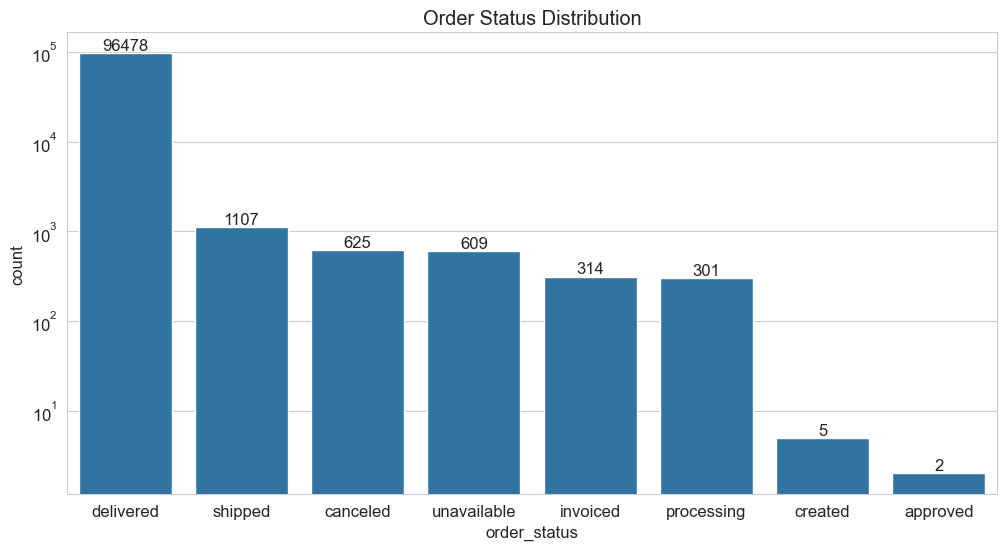

In [114]:
ax = sns.barplot(
    data=orders_status,
    x='order_status',
    y='count'
)

ax.set_yscale('log')
ax.bar_label(ax.containers[0])
ax.set_title('Order Status Distribution')
plt.show()

In [115]:
#the reason for the 43 missing value:
# - 141 Canceled / 5 Created: Expected behavior (order was stopped or hasn't reached approval step)
# - 14 Delivered: Data logging anomaly/bug (delivered to customer, but approval timestamp was not captured) or pay when the order is delivered
orders[orders['order_approved_at'].isna()]['order_status'].value_counts(dropna=False)

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [116]:
# 1. order_delivered_carrier_date (1783 missing values):
# - All 1783 missing values are logically expected.
# - The vast majority (1159) stem from canceled (550) or unavailable (609) orders that never left the seller's location.
# - The remaining orders (624) are still in early stages before handoff to the carrier (created, invoiced, processing,delivered).
orders[orders['order_delivered_carrier_date'].isna()]['order_status'].value_counts(dropna=False)

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [117]:
#  order_delivered_customer_date (692 missing values):
#   * 1107 orders are currently in transit ('shipped').
#   * 1228 orders were canceled or unavailable ('canceled': 619, 'unavailable': 609).
#   * 620 orders are in pre-shipping stages ('created', 'invoiced', 'processing').
# - Data Anomaly: 8 orders have status 'delivered' but lack a delivery timestamp may be will pay when the order is arrived 
orders[orders['order_delivered_customer_date'].isna()]['order_status'].value_counts(dropna=False)

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

## Calculating the Actuale Estemated time to deliver the order

In [118]:
delivered_df = orders[orders['order_status'] == 'delivered'].copy()

In [119]:
#calculating the orders that arrive on time
delivered_df['delivery_days'] = (
    delivered_df['order_delivered_customer_date']
    - delivered_df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

delivered_df['delivery_days'].head(10)

0      8.436574
1     13.782037
2      9.394213
3     13.208750
4      2.873877
5     16.542245
7      9.989826
8      9.818762
9     18.221852
10    12.650937
Name: delivery_days, dtype: float64

In [120]:
#calculating the orders that arrived late
delivered_df['delivery_delay_days'] = (
    delivered_df['order_delivered_customer_date']
    - delivered_df['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

delivered_df['delivery_delay_days'].head(10)

0     -7.107488
1     -5.355729
2    -17.245498
3    -12.980069
4     -9.238171
5     -5.543113
7    -11.461215
8    -31.410995
9     -6.281597
10    -8.528808
Name: delivery_delay_days, dtype: float64

In [121]:
delivered_df['delivery_status'] = np.where(
    delivered_df['delivery_delay_days'] > 0,
    'Late',
    'On Time'
)

In [122]:
delivered_df['delivery_status'].value_counts()

delivery_status
On Time    88652
Late        7826
Name: count, dtype: int64

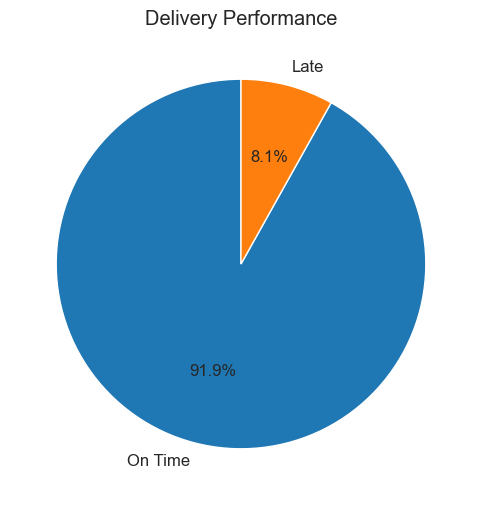

In [123]:
# Calculate counts for delivery status
delivery_counts = delivered_df['delivery_status'].value_counts()

# Create the pie chart for delivery performance
plt.pie(
    delivery_counts,
    labels=delivery_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Delivery Performance')
plt.show()

In [124]:
monthly_orders = (
    orders
    .set_index('order_purchase_timestamp')
    .resample('ME')
    .size()
)
monthly_orders.head()

order_purchase_timestamp
2016-09-30      4
2016-10-31    324
2016-11-30      0
2016-12-31      1
2017-01-31    800
Freq: ME, dtype: int64

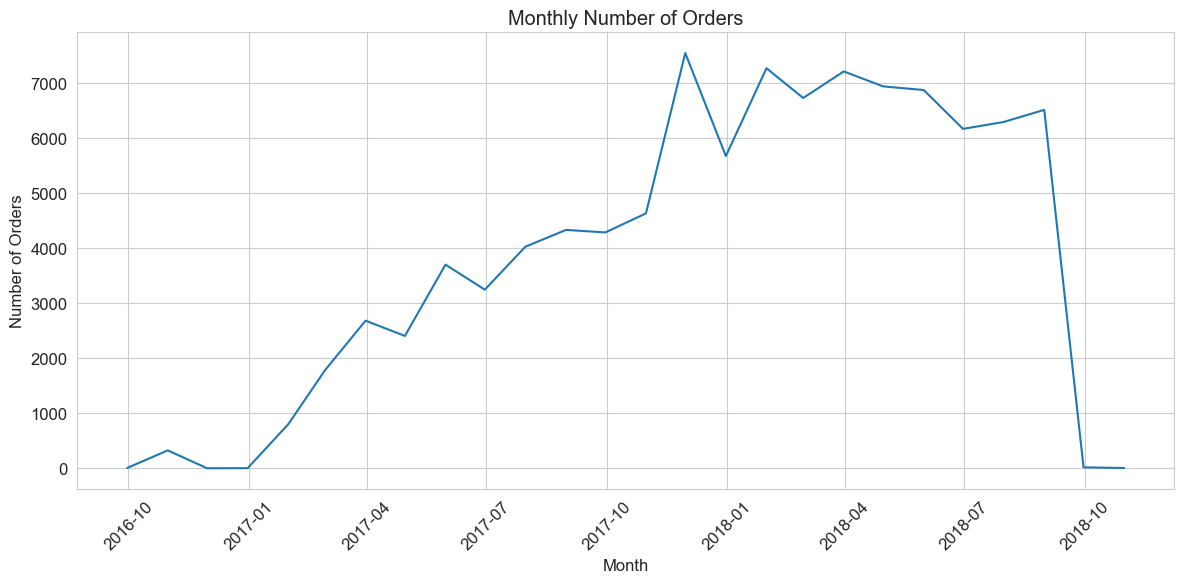

In [125]:
plt.plot(monthly_orders.index, monthly_orders.values)

plt.title('Monthly Number of Orders')
plt.xlabel('Month')
plt.ylabel('Number of Orders')


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Working on Order_item dataset

In [126]:
items.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [127]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [128]:
items['shipping_limit_date'] = items['shipping_limit_date'].apply(pd.to_datetime)

In [129]:
items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [130]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [131]:
items['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [132]:
items['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

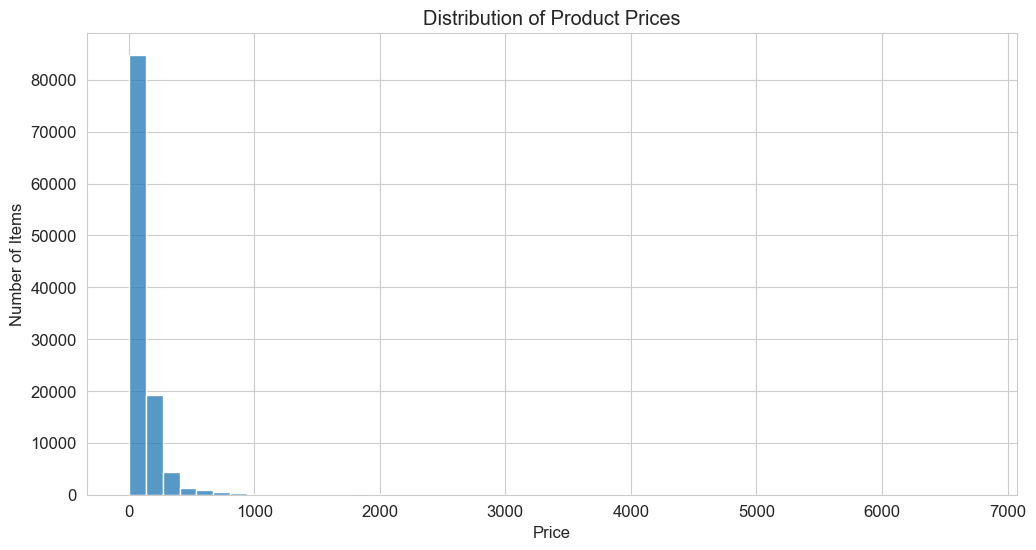

In [133]:
sns.histplot(items['price'], bins=50)

plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Number of Items')

plt.show()

In [134]:
#check the duplicates of order_id
items['order_id'].duplicated().sum()

np.int64(13984)

# Working on product data set

In [135]:
products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [136]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [137]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [138]:
# fill the missing value
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [139]:
cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']

products[cols] = products[cols].fillna(0)

In [140]:
cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
products[cols] = products[cols].fillna(products[cols].median())

In [141]:
products.isna().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [142]:
products.head(20)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


In [143]:
products.duplicated().sum()

np.int64(0)

In [144]:
#merging products table and categories table 
products = pd.merge(products, categories, "inner", "product_category_name")

In [145]:
#merging products table and order_item table this help me to know the most categories have the highest revnue 
categorized_order_item=pd.merge(items,products,"inner","product_id")

In [146]:
# rename columns
categorized_order_item = categorized_order_item.rename(columns={'product_category_name_english': 'product_category'})


In [147]:
# sum the total price of order items grouped by order_id
order_totals = (
    items
    .groupby('order_id', as_index=False)
    .agg({'price': 'sum', 'freight_value': 'sum'})
    .rename(columns={'price': 'total_price', 'freight_value': 'total_freight_value'})
)

In [148]:
order_details =orders.merge(order_totals, 'left', 'order_id')

In [149]:
order_details

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,72.00,13.08
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,174.90,20.10
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,205.99,65.02
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,359.98,81.18


# Woring on customer dataset

In [150]:
customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [151]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [152]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [153]:
customers.duplicated().sum()

np.int64(0)

In [154]:
# merge order_details and customers that help in asnwer which region have the highest customer value
order_details = order_details.merge(
    customers[['customer_id', 'customer_city', 'customer_state']], 
    'left', 
    'customer_id'
)

In [155]:
order_details

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight_value,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,72.00,13.08,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,174.90,20.10,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,205.99,65.02,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,359.98,81.18,japuiba,RJ


# Working on order_seller dataset

In [156]:
sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [157]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [158]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [159]:
# sum total seller revenue from df_order_items
total_seller_revenue = (
    items
    .groupby('seller_id')['price']
    .agg('sum')
)

In [160]:
sellers_revnue=sellers.merge(total_seller_revenue,"left","seller_id")

In [161]:
sellers_revnue

,seller_id,seller_zip_code_prefix,seller_city,seller_state,price
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,218.70
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,11703.07
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,158.00
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,79.99
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,167.99
...,...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR,158.00
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC,889.00
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP,550.04
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS,297.00


In [162]:
# sum of total customer spending
total_cust_spending = (
    order_details
    .groupby('customer_id')
    .agg({
        'total_price': 'sum',
        'total_freight_value': 'sum'
    })
)

In [163]:
customer_spending = customers.merge(total_cust_spending,'left','customer_id')

In [164]:
customer_spending

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,230.00,22.25
...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,74.90,13.88
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,114.90,14.16
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,37.00,19.04
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,689.00,22.07


# Visualization

In [165]:
#the most city have large number of orders
order_city_counts = (
    order_details['customer_city']
    .value_counts()
    .reset_index()
    .head(10)
    .rename(columns={'count': 'orders'})
)

order_city_counts

,customer_city,orders
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


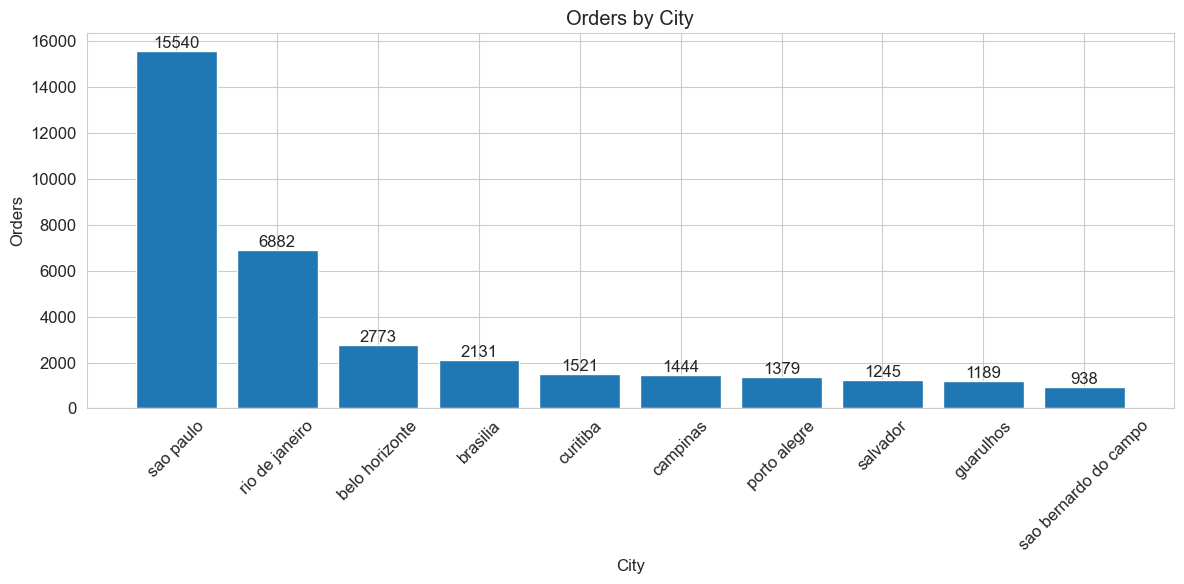

In [166]:
bars = plt.bar(order_city_counts['customer_city'], order_city_counts['orders'])

plt.bar_label(bars)

plt.title('Orders by City')
plt.xlabel('City')
plt.ylabel('Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [167]:
order_city_counts = (
    order_details['customer_city']
    .value_counts()
    .reset_index()
    .tail(10)
    .rename(columns={'count': 'orders'})
)

order_city_counts

,customer_city,orders
4109,nobres,1
4110,cipo-guacu,1
4111,paineiras,1
4112,riachuelo,1
4113,murici,1
4114,vila nova do sul,1
4115,cuite velho,1
4116,novais,1
4117,jacuipe,1
4118,nova vicosa,1


# Product distribution by Category

In [168]:

category_dist = (
    products['product_category_name_english']
    .value_counts()
    .reset_index()
    .rename(columns={
        'product_category_name_english':'product_category',
        'count': 'product_count'
    })
    .head(10)
)
category_dist

,product_category,product_count
0,bed_bath_table,3029
1,sports_leisure,2867
2,furniture_decor,2657
3,health_beauty,2444
4,housewares,2335
5,auto,1900
6,computers_accessories,1639
7,toys,1411
8,watches_gifts,1329
9,telephony,1134


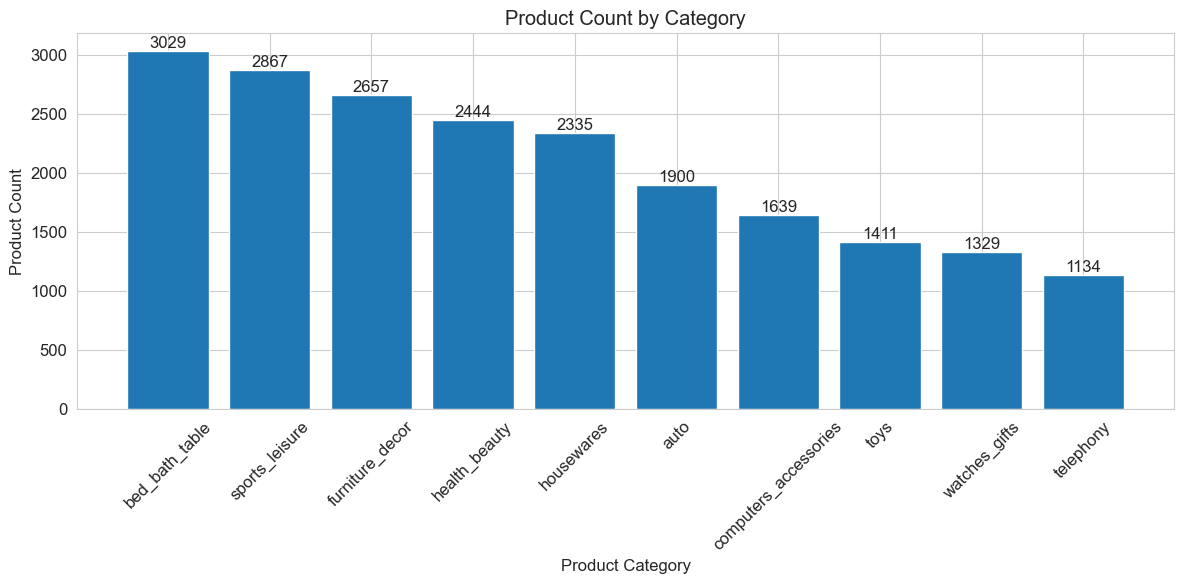

In [169]:
bars = plt.bar(
    category_dist['product_category'], 
    category_dist['product_count']
)

plt.bar_label(bars)

plt.title('Product Count by Category')
plt.xlabel('Product Category')
plt.ylabel('Product Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# which region have the most seller?

In [170]:
seller_by_cities = (
    sellers_revnue['seller_city']
    .value_counts()
    .reset_index()
    .rename(columns={
        'seller_city': 'city',
        'count': 'seller_count'
    })
    .head(10)
)

seller_by_cities

,city,seller_count
0,sao paulo,694
1,curitiba,127
2,rio de janeiro,96
3,belo horizonte,68
4,ribeirao preto,52
5,guarulhos,50
6,ibitinga,49
7,santo andre,45
8,campinas,41
9,maringa,40


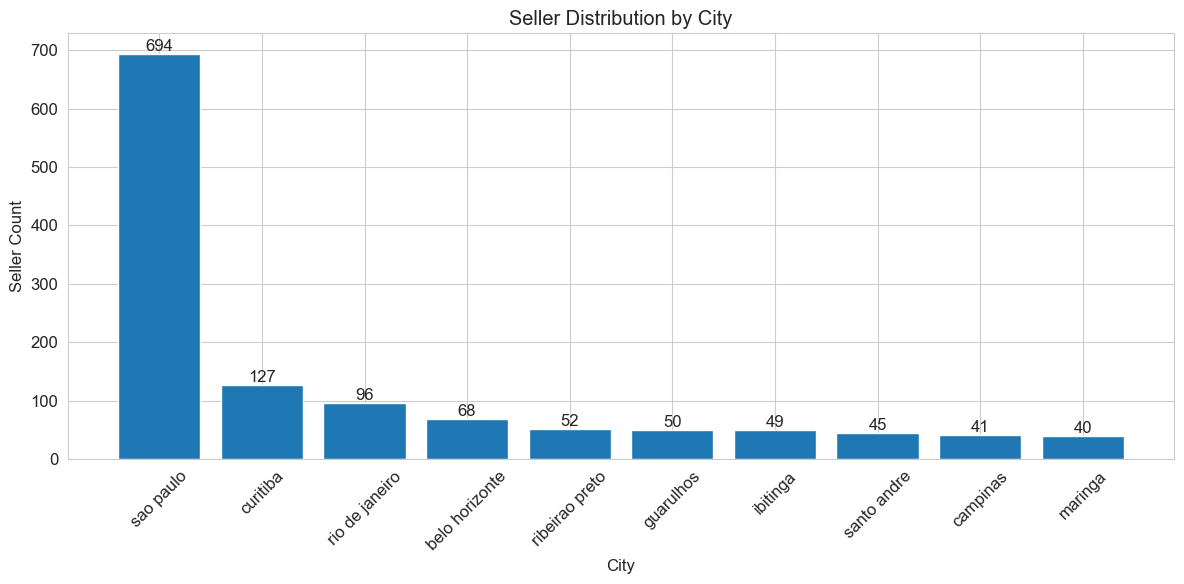

In [171]:
bars = plt.bar(
    seller_by_cities['city'], 
    seller_by_cities['seller_count']
)

plt.title('Seller Distribution by City')
plt.xlabel('City')
plt.ylabel('Seller Count')
plt.xticks(rotation=45)

plt.bar_label(bars)

plt.tight_layout()
plt.show()

# Which products and categories generate the most revenue?

In [172]:
products_revenue = (
    categorized_order_item
    .groupby(['product_id', 'product_category'])
    .agg({
        'price': 'sum'
    })
    .sort_values(by='price', ascending=False)
    .head()
)

products_revenue = products_revenue.rename(columns={'price': 'total_revenue'}).reset_index()

In [173]:
products_revenue

,product_id,product_category,total_revenue
0,bb50f2e236e5eea0100680137654686c,health_beauty,63885.00
1,6cdd53843498f92890544667809f1595,health_beauty,54730.20
2,d6160fb7873f184099d9bc95e30376af,computers,48899.34
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,47214.51
4,99a4788cb24856965c36a24e339b6058,bed_bath_table,43025.56


In [174]:
category_revenue = (
    categorized_order_item
    .groupby('product_category')
    .agg({'price': 'sum'})
    .sort_values(by='price', ascending=False)
    .reset_index()
    .head()
)

category_revenue = category_revenue.rename(columns={'price': 'total_revenue'})
category_revenue

,product_category,total_revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32


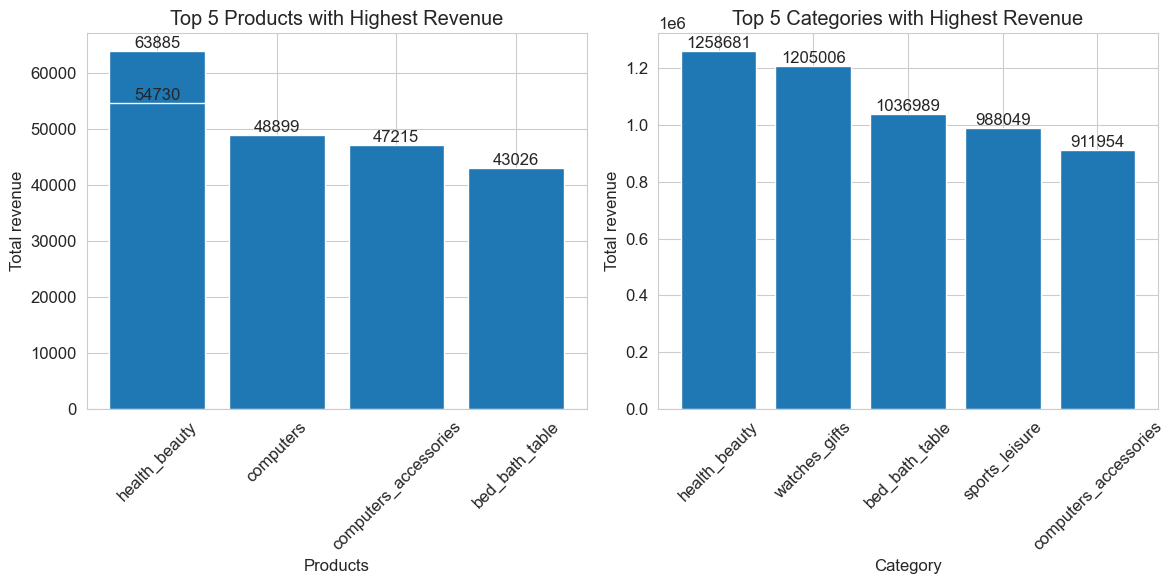

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 1. Top 5 products revenue (الشكل الأول)
bars1 = axes[0].bar(
    products_revenue['product_category'], 
    products_revenue['total_revenue']
)

axes[0].bar_label(bars1, fmt='%.0f')
axes[0].set_title('Top 5 Products with Highest Revenue')
axes[0].set_xlabel('Products')
axes[0].set_ylabel('Total revenue')
axes[0].tick_params(axis='x', rotation=45)

# 2. Top 5 category revenue (الشكل الثاني)
bars2 = axes[1].bar(
    category_revenue['product_category'], 
    category_revenue['total_revenue']
)

axes[1].bar_label(bars2, fmt='%.0f')
axes[1].set_title('Top 5 Categories with Highest Revenue')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# hich city have the highest sales?

In [176]:
city_sales = (
    order_details
    .groupby('customer_city')
    .agg({'total_price': 'sum'})
    .reset_index()
    .sort_values(by='total_price', ascending=False)
    .head()
)
city_sales

,customer_city,total_price
3597,sao paulo,1914924.54
3155,rio de janeiro,992538.86
453,belo horizonte,355611.13
558,brasilia,301920.25
1143,curitiba,211738.06


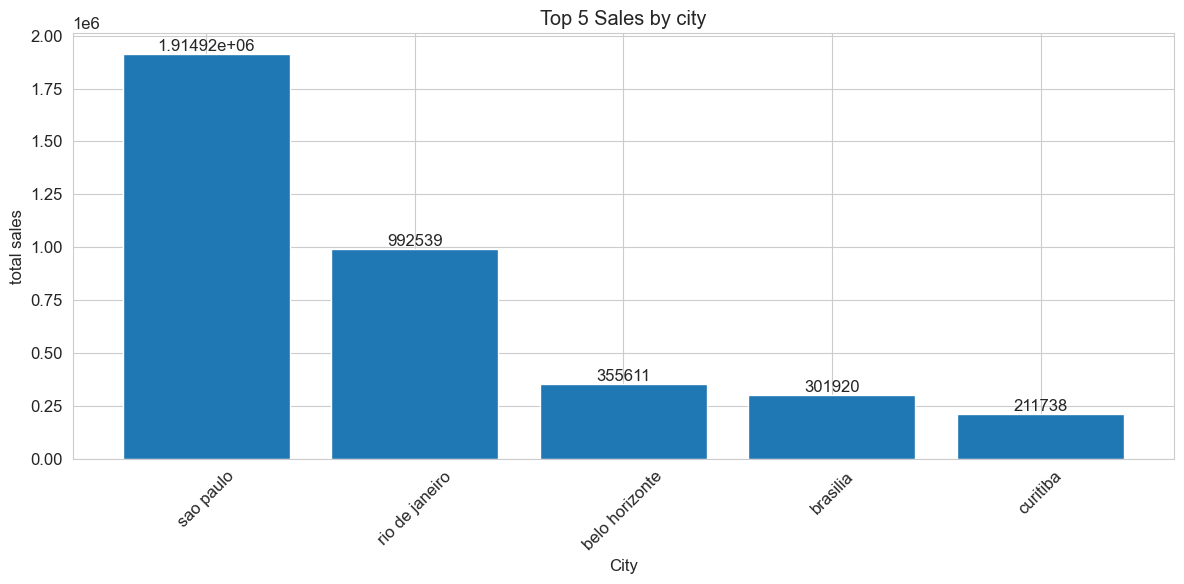

In [177]:
bars = plt.bar(
    city_sales['customer_city'], 
    city_sales['total_price']
)

plt.title('Top 5 Sales by city')
plt.xlabel('City')
plt.ylabel('total sales')
plt.xticks(rotation=45)

plt.bar_label(bars)

plt.tight_layout()
plt.show()

# Customer Segmentation (RFM)

In [178]:
cust_segment=order_details.merge(customers,"left",'customer_id')
cust_segment.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight_value,customer_city_x,customer_state_x,customer_unique_id,customer_zip_code_prefix,customer_city_y,customer_state_y
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,sao paulo,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,barreiras,BA,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,vianopolis,GO,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,sao goncalo do amarante,RN,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,santo andre,SP,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,147.90,27.36,congonhinhas,PR,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,49.90,16.05,santa rosa,RS,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,59.99,15.17,nilopolis,RJ,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,19.90,16.05,faxinalzinho,RS,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,149.99,19.77,sorocaba,SP,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP


In [179]:
rfm_df = cust_segment[cust_segment['order_status'] == 'delivered'].copy()

In [180]:
reference_date= rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
reference_date


Timestamp('2018-08-30 15:00:37')

In [181]:
RFM =(rfm_df.groupby("customer_unique_id").agg(
        Recency=("order_purchase_timestamp", lambda d: (reference_date - d.max()).days), # the result will be the Number of day
        Frequency=("order_id", "nunique"), # How many transaction the customer made?
        Monetary=("total_price", "sum"),   # the total amount of spent for each customer
    )
    .reset_index()
)

print(f"RFM table: {RFM.shape[0]} customers x {RFM.shape[1]} columns")
RFM.head(50)

RFM table: 93358 customers x 4 columns


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,154.00
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,27.99
7,00053a61a98854899e70ed204dd4bafe,183,1,382.00
8,0005e1862207bf6ccc02e4228effd9a0,543,1,135.00
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,104.90


In [182]:
#Scaling the Features
'''
 Recency is in days, frequency is a small count, monetary is in currency units — very different scales.
 K-Means uses Euclidean distance, so without scaling, "Monetary" would dominate the clustering just because its numbers are bigger ,
 so "StandardScaler" will fixe that
'''
scale=StandardScaler()
RFM_scaled=scale.fit_transform(RFM[['Recency','Frequency','Monetary']])

pd.DataFrame(RFM_scaled,columns=['Recency','Frequency','Monetary']).describe().round(1)

,Recency,Frequency,Monetary
count,93358.0,93358.0,93358.0
mean,-0.0,-0.0,0.0
std,1.0,1.0,1.0
min,-1.6,-0.2,-0.7
25%,-0.8,-0.2,-0.4
50%,-0.1,-0.2,-0.2
75%,0.7,-0.2,0.1
max,3.1,66.8,61.7


## Determine Optimal K: Elbow and Silhouette Methods

In [183]:
K_range = range(1, 11)
inertia = []
silhouette_scores = []  # only defined for K >= 2

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(RFM_scaled)
    inertia.append(kmeans.inertia_)

    if k >= 2:
        sil = silhouette_score(RFM_scaled, labels)

        
        silhouette_scores.append(sil)
        print(f"K={k}: Inertia = {kmeans.inertia_:,.1f} | Silhouette = {sil:.4f}")
    else:
        print(f"K={k}: Inertia = {kmeans.inertia_:,.1f} | Silhouette = N/A")

K=1: Inertia = 280,074.0 | Silhouette = N/A
K=2: Inertia = 201,978.1 | Silhouette = 0.7392
K=3: Inertia = 138,056.6 | Silhouette = 0.4593
K=4: Inertia = 92,050.9 | Silhouette = 0.4907
K=5: Inertia = 77,351.9 | Silhouette = 0.4218
K=6: Inertia = 63,305.2 | Silhouette = 0.4395
K=7: Inertia = 53,907.7 | Silhouette = 0.4440
K=8: Inertia = 48,242.0 | Silhouette = 0.4518
K=9: Inertia = 43,383.8 | Silhouette = 0.3871
K=10: Inertia = 39,364.2 | Silhouette = 0.3960


## Visualize Optimal K Determination

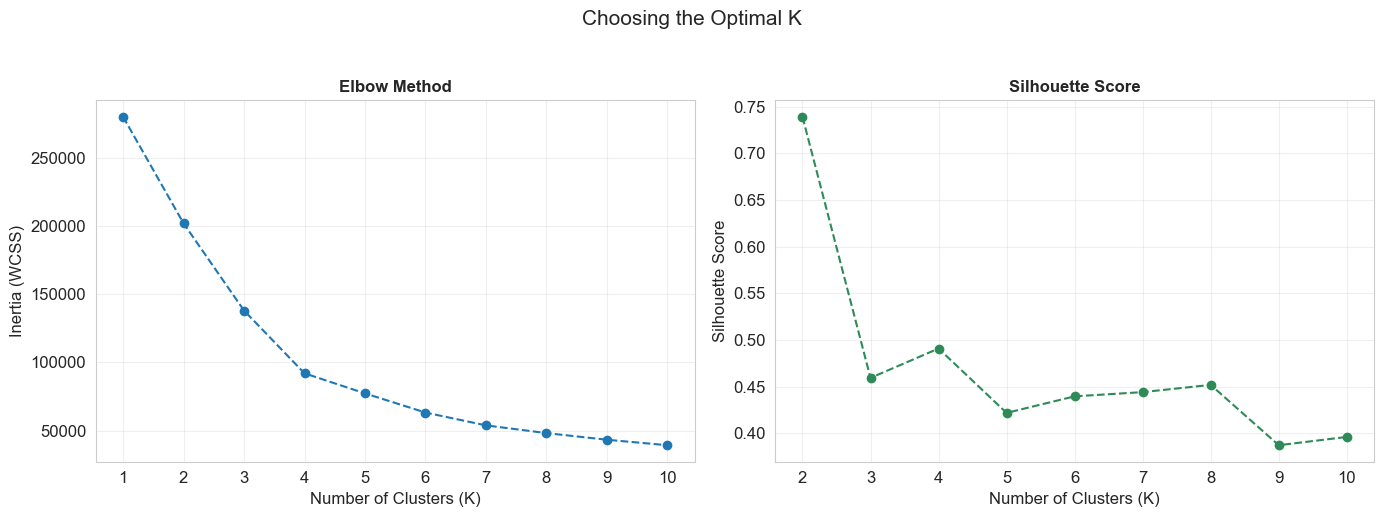

K with the highest silhouette score: 2 (0.7392)


In [184]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', linestyle='--')
axes[0].set_title("Elbow Method", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_xticks(K_range)
axes[0].grid(alpha=0.3)

sil_K = range(2, 11)
axes[1].plot(sil_K, silhouette_scores, marker='o', linestyle='--', color='seagreen')
axes[1].set_title("Silhouette Score", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(sil_K)
axes[1].grid(alpha=0.3)

plt.suptitle("Choosing the Optimal K", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

best_k = list(sil_K)[np.argmax(silhouette_scores)]
print(f"K with the highest silhouette score: {best_k} ({max(silhouette_scores):.4f})")

In [185]:
optimal_k = 3
# Baseed on highest silhouette score and elbow bend after adding another cluster
# 3 is the best k for maximum granularity which is more useful for an RFM data than maximum seperation using k =2

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
RFM['Cluster'] = kmeans_final.fit_predict(RFM_scaled)

print(RFM['Cluster'].value_counts().sort_index())

cluster_profile = RFM.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Customers=('customer_unique_id', 'count')
).round(1)

cluster_profile

Cluster
0    52060
1    38491
2     2807
Name: count, dtype: int64


,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,128.2,1.0,136.2,52060
1,387.6,1.0,139.2,38491
2,220.4,2.1,276.1,2807


In [186]:
# Add business-friendly persona names
persona_names = {
    0: 'Champions / VIP',
    1: 'Regular Customers',
    2: 'At Risk'
}

# Add Persona column to the cluster profile
cluster_profile['Persona'] = cluster_profile.index.map(persona_names)

# Calculate customer percentage
cluster_profile['Customer_%'] = (
    cluster_profile['Customers'] / cluster_profile['Customers'].sum() * 100
).round(1)

# Reorder columns
cluster_profile = cluster_profile[
    ['Persona', 'Customers', 'Customer_%', 'Recency', 'Frequency', 'Monetary']
]

cluster_profile

,Persona,Customers,Customer_%,Recency,Frequency,Monetary
Cluster,,,,,,
0,Champions / VIP,52060,55.8,128.2,1.0,136.2
1,Regular Customers,38491,41.2,387.6,1.0,139.2
2,At Risk,2807,3.0,220.4,2.1,276.1


## Visualize Customer Segments with PCA

##### Cluster 0 — VIP Customers
Frequent, high-spending customers. Focus on loyalty and special offers.

##### Cluster 1 — Regular Customers
Average activity and spending. Use promotions to increase purchases.

##### Cluster 2 — Dormant Customers
Low activity and spending, with no recent purchases. Use offers to bring them back.



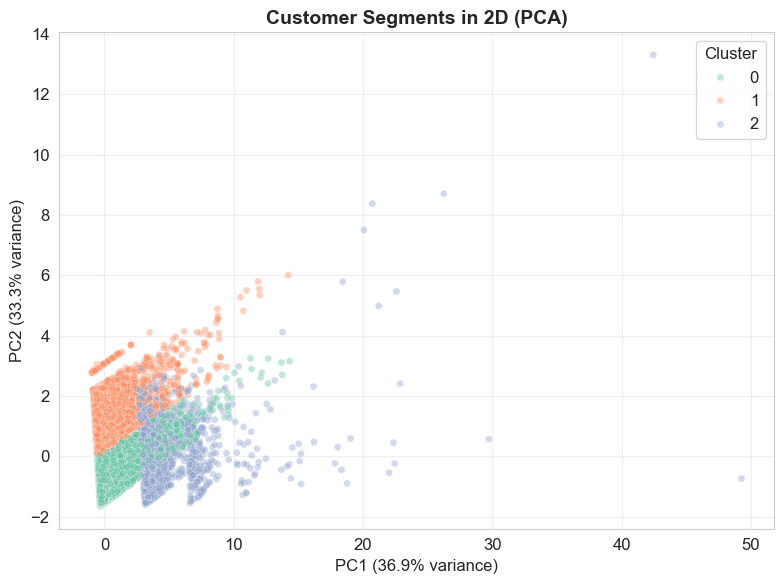

Total variance explained by PC1 + PC2: 70.3%


In [193]:
# Reduce the scaled RFM features to 2 dimensions with PCA, just for plotting
pca = PCA(n_components=2, random_state=42)
RFM_pca = pca.fit_transform(RFM_scaled)

RFM['PCA1'] = RFM_pca[:, 0]
RFM['PCA2'] = RFM_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=RFM, x='PCA1', y='PCA2',
    hue='Cluster', palette='Set2', s=25, alpha=0.4, edgecolor='white'
)
plt.title('Customer Segments in 2D (PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%')